<a href="https://colab.research.google.com/github/hombremono873/Cuadernos_colab/blob/main/Omar_torres_Diego_Alejandro_Roa_Actividad4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Universidad Santo Tomás**
**Asignatura:** Ciencia de Datos  
**Estudiante:** Omar Alberto Torres, Diego Alejandro Roa Lara.  
**Profesor:**   Diego Ricardo Páez Ardila.  
**Título del Proyecto:** Identificar Perfiles de estudiantes.
**Fecha de Entrega:** Septiembre 2026.
---

# **1. Contexto del dataset**

El conjunto de datos utilizado en este proyecto se denomina **Student Career Success Prediction Dataset** y está publicado en la plataforma **Kaggle** por el usuario **Mobeen Fatimah**. El dataset está orientado al análisis de diferentes características relacionadas con estudiantes y su posible trayectoria o éxito profesional.

La información contenida en el conjunto de datos permite analizar diferentes aspectos asociados con el perfil de los estudiantes, incluyendo características académicas, personales y relacionadas con su desarrollo profesional. Este tipo de información puede ser utilizada para identificar patrones y relaciones entre las características de los estudiantes.

Desde la perspectiva del análisis de datos, el conjunto de datos ofrece la posibilidad de estudiar si existen **perfiles o grupos de estudiantes que presenten características similares**. Esta posibilidad resulta especialmente interesante para un enfoque de aprendizaje automático no supervisado, debido a que el objetivo no será predecir una categoría previamente conocida, sino explorar la estructura interna de los datos.

En este proyecto se utilizará el dataset como base para desarrollar un modelo de **clustering mediante el algoritmo K-Means**. El propósito será analizar si las características disponibles permiten identificar grupos relativamente homogéneos de estudiantes.

Es importante señalar que la existencia y el significado de estos grupos no se asumirán previamente. Los clusters deberán ser obtenidos mediante el análisis de los datos y posteriormente interpretados a partir de las características que los diferencien.

Por lo tanto, el proyecto se plantea desde una perspectiva exploratoria: **utilizar técnicas de aprendizaje no supervisado para descubrir posibles perfiles de estudiantes presentes en el conjunto de datos y analizar las características que permiten diferenciarlos**.

La fuente del conjunto de datos es Kaggle:

**Dataset:** Student Career Success Prediction Dataset
**Autor/publicador:** Mobeen Fatimah
**Plataforma:** Kaggle
**Fuente:** https://www.kaggle.com/datasets/mobeenfatimah/student-career-success-prediction-dataset


# **El problema**

## **4.1 Formulación del problema**

El conjunto de datos **Student Career Success Prediction Dataset** contiene diferentes características relacionadas con estudiantes y aspectos de su trayectoria académica y profesional. Aunque este tipo de información puede utilizarse para realizar predicciones mediante aprendizaje supervisado, en este proyecto se plantea un enfoque de **aprendizaje no supervisado**.

El problema consiste en determinar si, a partir de las características disponibles de los estudiantes, es posible **identificar grupos o perfiles de estudiantes con características similares**, sin utilizar previamente una clasificación o etiqueta que indique a qué grupo pertenece cada estudiante.

Para abordar este problema se utilizará el algoritmo **K-Means** y **DBSCAN**, una técnica de agrupamiento que permite dividir las observaciones en un número determinado de grupos, buscando que los estudiantes pertenecientes a un mismo grupo presenten características similares y que los estudiantes pertenecientes a grupos diferentes presenten características relativamente distintas.

El análisis permitirá explorar la estructura interna del conjunto de datos y determinar si existen patrones que permitan caracterizar diferentes perfiles de estudiantes.

## **4.2 Pregunta de investigación**

¿Es posible identificar grupos homogéneos de estudiantes a partir de sus características académicas, personales y profesionales mediante los algoritmos de aprendizaje no supervisado K-Means, y DBSCAN ?

## **4.3 Objetivo general**

Identificar y caracterizar grupos de estudiantes con características similares mediante la aplicación de los  algoritmo **K-Means** y **DBSCAN** sobre las variables relevantes del Student Career Success Prediction Dataset.

## **4.4 Objetivos específicos**

1. Analizar la estructura y las características del conjunto de datos para identificar las variables relevantes para el proceso de agrupamiento.

2. Realizar un análisis exploratorio de los datos con el propósito de identificar valores faltantes, valores atípicos, variables inconsistentes y posibles problemas que puedan afectar el proceso de clustering.

3. Preparar y transformar las variables seleccionadas de acuerdo con los requerimientos de los algoritmos **K-Means** y **DBCAN**.

4. Aplicar los algoritmos **K-Means** y **DBSCAN** para identificar diferentes grupos de estudiantes con características similares.

5. Analizar diferentes valores de **k** mediante criterios de evaluación apropiados para determinar una cantidad razonable de clusters.

6. Evaluar e interpretar las características de los grupos obtenidos para identificar los perfiles que diferencian a los estudiantes.

7. Analizar las limitaciones de los resultados obtenidos y establecer posibles líneas de mejora para futuros análisis.

## **4.5 Tipo de problema de Machine Learning**

El problema corresponde a **aprendizaje automático no supervisado**, específicamente a una tarea de **clustering o agrupamiento**.

A diferencia de un problema de clasificación supervisada, en este proyecto no se utilizará una variable objetivo previamente etiquetada para entrenar el modelo. El algoritmo buscará descubrir estructuras o grupos presentes en los datos a partir de las características proporcionadas.

## **Representación conceptual**

El proceso puede representarse de la siguiente manera:

**Características de los estudiantes → Preparación de los datos → K-Means/DBSCAN → Grupos de estudiantes → Interpretación de los perfiles**

El resultado esperado no es una predicción de una categoría conocida, sino el **descubrimiento de posibles grupos o perfiles de estudiantes presentes en los datos**.


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import seaborn as sns
import os

# **3. Caracterización técnica del dataset**

In [ ]:
"""
Obtenemos la ruta del dataset desde kaggle, y verificamos el nombre de los archivos que contiena

"""

path = kagglehub.dataset_download("mobeenfatimah/student-career-success-prediction-dataset")

# 2. Lista todos los archivos dentro de esa carpeta
print("Archivos encontrados en el dataset:")
for archivo in os.listdir(path):
    print(archivo)

100%|██████████| 1.46M/1.46M [00:00<00:00, 49.3MB/s]

Extracting files...
Archivos encontrados en el dataset:
student_career_success_dataset.csv


# **3.1 Dimensiones del dataset**

In [ ]:
archivo = os.path.join(path, "student_career_success_dataset.csv")
df = pd.read_csv(archivo)
print(f"Dimenciones del dataset: {df.shape}\n")
print(f"Columnas del dataset: {df.columns}")

Dimenciones del dataset: (50000, 29)

Columnas del dataset: Index(['Student_ID', 'Age', 'Gender', 'University_Year', 'Major',
       'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA',
       'Academic_Performance', 'Programming_Skill', 'Projects_Completed',
       'Certifications', 'Hackathons', 'GitHub_Profile', 'Internships',
       'Leadership_Experience', 'LinkedIn_Profile', 'Resume_Score',
       'Communication_Skills', 'Teamwork', 'Problem_Solving',
       'English_Proficiency', 'Interview_Score', 'Employability_Score',
       'Placement_Status', 'Company_Tier', 'Career_Field', 'Placement_Mode',
       'Starting_Salary_USD'],
      dtype='object')


# **3.2 Variables del dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   University_Year        50000 non-null  object 
 4   Major                  50000 non-null  object 
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  object 
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  object 
 14  Internships            50000 non-null  int64  
 15  Le

## **3.2.1 Variables del dataset**

El conjunto de datos **Student Career Success Prediction Dataset** está compuesto por **50.000 registros y 29 variables**. De acuerdo con la información obtenida mediante **df.info()**, todas las variables contienen **50.000 valores no nulos**, por lo que no se identifican valores faltantes en esta revisión inicial.

Las 29 variables se distribuyen en **16 variables numéricas** (14 de tipo **int64**), 2 de tipo (**float64**), y (**13 variables de tipo object**), que corresponden principalmente a variables categóricas o de texto.

Entre las variables se encuentra **Student_ID**, que corresponde a un identificador del estudiante y que deberá analizarse posteriormente para determinar si debe excluirse del proceso de agrupamiento. Las demás variables contienen información relacionada con características demográficas, académicas, habilidades, experiencia, empleabilidad y resultados profesionales de los estudiantes.

Esta caracterización corresponde únicamente a una **inspección inicial de la estructura del dataset**. La selección de las variables que serán utilizadas en **K-Means** y **DBSCAN** se realizará posteriormente, después del análisis exploratorio y de la evaluación de la naturaleza y relevancia de cada variable.


# **3.2.2 Visualización minima de muestras**

In [ ]:
df.head()

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


In [ ]:
df["Gender"].unique()

array(['Male', 'Female', 'Other'], dtype=object)

## **3.3. 3 Descripción de las variables**

* **Student_ID**: Identificador único asignado a cada estudiante.

* **Age**: Edad del estudiante, expresada en años.

* **Gender**: Género del estudiante.

* **University_Year**: Año académico que cursa el estudiante.

* **Major**: Programa o área de formación académica del estudiante.

* **Attendance_Percentage**: Porcentaje de asistencia del estudiante a sus actividades académicas.

* **Study_Hours_Per_Week**: Número de horas dedicadas al estudio por semana.

* **CGPA**: Promedio académico acumulado del estudiante.

* **Academic_Performance**: Nivel de rendimiento académico del estudiante.

* **Programming_Skill**: Nivel de habilidad en programación.

* **Projects_Completed**: Número de proyectos completados por el estudiante.

* **Certifications**: Número de certificaciones obtenidas.

* **Hackathons**: Número de hackatones (eventos) en los que ha participado.

* **GitHub_Profile**: Indica si el estudiante dispone de un perfil en GitHub.

* **Internships**: Número de prácticas o pasantías realizadas.

* **Leadership_Experience**: Indica si el estudiante posee experiencia en liderazgo.

* **LinkedIn_Profile**: Indica si el estudiante dispone de un perfil en LinkedIn.

* **Resume_Score**: Puntuación obtenida por el estudiante en la evaluación de su hoja de vida.

* **Communication_Skills**: Puntuación asociada a las habilidades de comunicación.

* **Teamwork**: Puntuación asociada a las habilidades de trabajo en equipo.

- **Gender**: Género del estudiante. Presenta las categorías **Male**, **Female** y **Other**.

* **Problem_Solving**: Puntuación asociada a la capacidad de resolución de problemas.

* **English_Proficiency**: Nivel de dominio del idioma inglés.

* **Interview_Score**: Puntuación obtenida en las entrevistas.

* **Employability_Score**: Puntuación que representa el nivel de empleabilidad del estudiante.

* **Placement_Status**: Estado de colocación laboral del estudiante.

* **Company_Tier**: Categoría o nivel de la empresa en la que fue colocado el estudiante.

* **Career_Field**: Campo o área profesional asociada al estudiante.

* **Placement_Mode**: Modalidad mediante la cual se produjo la colocación laboral.

* **Starting_Salary_USD**: Salario inicial del estudiante expresado en dólares estadounidenses.


## **4. Tipos de variables**

Las variables del dataset se clasifican según su naturaleza y, en el caso de las variables categóricas, según la existencia o no de un orden entre sus categorías.

### **Variable identificadora**

* **Student_ID**: Variable identificadora. Permite identificar de manera única a cada estudiante y no representa una característica para medir similitud entre estudiantes.

### **Variables numéricas**

- **Age**: Numérica.
- **Attendance_Percentage**: Numérica.
- **Study_Hours_Per_Week**: Numérica.
- **CGPA**: Numérica.
- **Programming_Skill**: Numérica.
- **Projects_Completed**: Numérica.
- **Certifications**: Numérica.
- **Hackathons**: Numérica.
- **Internships**: Numérica.
- **Resume_Score**: Numérica.
 **Communication_Skills**: Numérica.
- **Teamwork**: Numérica.
- **Problem_Solving**: Numérica.
- **Interview_Score**: Numérica.
- **Employability_Score**: Numérica.
- **Starting_Salary_USD**: Numérica.

### **Variables categóricas nominales**

Son variables cuyas categorías representan grupos o características diferentes, pero **no existe un orden jerárquico natural entre ellas**.

- **`Gender**: Categórica nominal. Categorías: **Male**, **Female** y **Other**.
- **Major**: Categórica nominal. Representa el programa o área académica.
- **GitHub_Profile**: Categórica nominal. Indica la presencia o ausencia de un perfil en GitHub.
- **Leadership_Experience**: Categórica nominal. Indica la presencia o ausencia de experiencia de liderazgo.
- **LinkedIn_Profile**: Categórica nominal. Indica la presencia o ausencia de un perfil en LinkedIn.
- **Placement_Status**: Categórica nominal. Indica si el estudiante fue colocado laboralmente o no.
- **Career_Field**: Categórica nominal. Representa el campo profesional asociado al estudiante.
- **Placement_Mode**: Categórica nominal. Representa la modalidad mediante la cual se produjo la colocación.

### **Variables categóricas ordinales**

Son variables cuyas categorías **presentan un orden lógico o jerárquico**.

- **University_Year**: Categórica ordinal. Representa el avance académico del estudiante: **Freshman**, **Sophomore**, **Junior** y
**Senior**.
- **Academic_Performance**: Categórica ordinal. Representa niveles de rendimiento académico como **Poor**, **Average** y **Good**.
- **English_Proficiency**: Categórica ordinal. Representa niveles de dominio del inglés como **Basic**, **Intermediate** y **Advanced**.
* **Company_Tier**: Categórica ordinal. Representa diferentes niveles o categorías de empresas, donde existe una jerarquía entre los niveles.

### **Resumen**

El dataset contiene **16 variables numéricas, 8 categóricas nominales, 5 categóricas ordinales y 1 variable identificadora**, para un total de **30 clasificaciones**.

1. 50.000 registros.
2. 29 variables.
3. Tipos de variables.
4. Variable identificadora.
5. Variables numéricas.
6. Variables categóricas nominales.
7. Variables categóricas ordinales.


# **4. Análisis exploratorio de los datos (EDA)**

In [ ]:
df.describe()

,Age,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,Internships,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,Interview_Score,Employability_Score,Starting_Salary_USD
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,21.262900,81.409640,21.52816,3.106043,7.137160,8.620560,1.715660,3.093940,4.048880,96.045740,8.435780,7.006200,7.175060,77.515400,213.991394,68988.167480
std,2.041163,9.709519,6.97481,0.290351,1.507194,2.505408,1.368301,1.660774,1.005719,7.331565,1.387543,1.606802,1.674428,12.579382,26.824224,38480.607679
min,18.000000,50.000000,5.00000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,44.000000,3.000000,2.000000,1.000000,17.000000,82.300000,0.000000
25%,20.000000,75.000000,17.00000,2.910000,6.000000,7.000000,1.000000,2.000000,3.000000,95.000000,7.000000,6.000000,6.000000,70.000000,197.350000,65229.250000
50%,21.000000,82.000000,21.00000,3.110000,7.000000,9.000000,2.000000,3.000000,4.000000,100.000000,9.000000,7.000000,7.000000,78.000000,217.250000,83044.500000
75%,22.000000,88.000000,26.00000,3.310000,8.000000,10.000000,3.000000,4.000000,5.000000,100.000000,10.000000,8.000000,8.000000,87.000000,233.600000,96486.250000
max,30.000000,100.000000,45.00000,4.000000,10.000000,15.000000,8.000000,10.000000,5.000000,100.000000,10.000000,10.000000,10.000000,100.000000,279.050000,110000.000000


In [ ]:
"""

Se verifica existencia de nulos

"""
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
University_Year,0
Major,0
Attendance_Percentage,0
Study_Hours_Per_Week,0
CGPA,0
Academic_Performance,0
Programming_Skill,0


In [ ]:
"""
Se  verifica existencia de duplicados

"""
df.duplicated().sum()

np.int64(0)

## **4.1 Estadística descriptiva de las variables numéricas**

El análisis descriptivo de las 16 variables numéricas muestra que todas cuentan con **50.000 observaciones**, por lo que no se identifican valores faltantes en esta primera revisión.

Las variables presentan diferentes rangos y escalas. La **edad** de los estudiantes se encuentra entre 18 y 30 años, con una media de 21,26 años. El porcentaje de **asistencia** presenta una media de 81,41 %, mientras que las horas de estudio semanales tienen una media de 21,53 horas.

El **CGPA** presenta una media de 3,11 sobre un rango de 2,00 a 4,00. Las variables relacionadas con habilidades, como programación, comunicación, trabajo en equipo y resolución de problemas, presentan valores dentro de escalas relativamente pequeñas, mientras que variables como proyectos, certificaciones, hackatones e internados representan cantidades de actividades o experiencias.

La variable **Employability_Score** presenta una media de 213,99 y un rango entre 82,30 y 279,05. Por su parte, **Starting_Salary_USD** presenta una media de 68.988,17 dólares y un rango considerablemente amplio entre 0 y 110.000 dólares.

Las diferencias entre las escalas de las variables son relevantes para el proyecto, ya que K-Meansy DBSCAN utiliza **distancias entre observaciones** para formar los grupos. Por esta razón, posteriormente será necesario analizar el efecto de las escalas y determinar si las variables requieren transformación o estandarización antes de aplicar el algoritmo.

En esta etapa no se eliminan ni transforman variables. El objetivo es únicamente **conocer la distribución y las escalas de las variables numéricas** para orientar los análisis posteriores.


# **4.2 Se verifica existencia de categorias**

In [ ]:
df.select_dtypes(include="object").nunique()

,0
Student_ID,50000
Gender,3
University_Year,4
Major,8
Academic_Performance,4
GitHub_Profile,2
Leadership_Experience,2
LinkedIn_Profile,2
English_Proficiency,3
Placement_Status,2


# **4.3 analisis de la cardinalidad de las categorías.**

El análisis de las variables categóricas permite identificar la cantidad de categorías diferentes presentes en cada variable. Se observa que **Student_ID** posee 50.000 valores únicos, lo que confirma su carácter de identificador individual.

1. **Gender**: 3 categorías.
2. **University_Year**: 4 categorías.
3. **Academic_Performance**: 4 categorías.
4. **English_Proficiency**: 3 categorías.
5. **Major**: 8 categorías.
6. **Career_Field**: 17 categorías.
7. **GitHub_Profile**: 2 categorías.
8. **Leadership_Experience**: 2 categorías.
9. **LinkedIn_Profile**: 2 categorías.
10. **Placement_Status**: 2 categorías.
11. **Company_Tier**: 4 categorías.
12. **Placement_Mode**: 5 categorías.

Esta revisión permite conocer la diversidad de las variables categóricas y será útil posteriormente para determinar cuáles pueden ser incorporadas al proceso de clustering y qué transformación sería apropiada para aquellas que resulten relevantes.

# **4.4 Distribución de las variables categóricas**

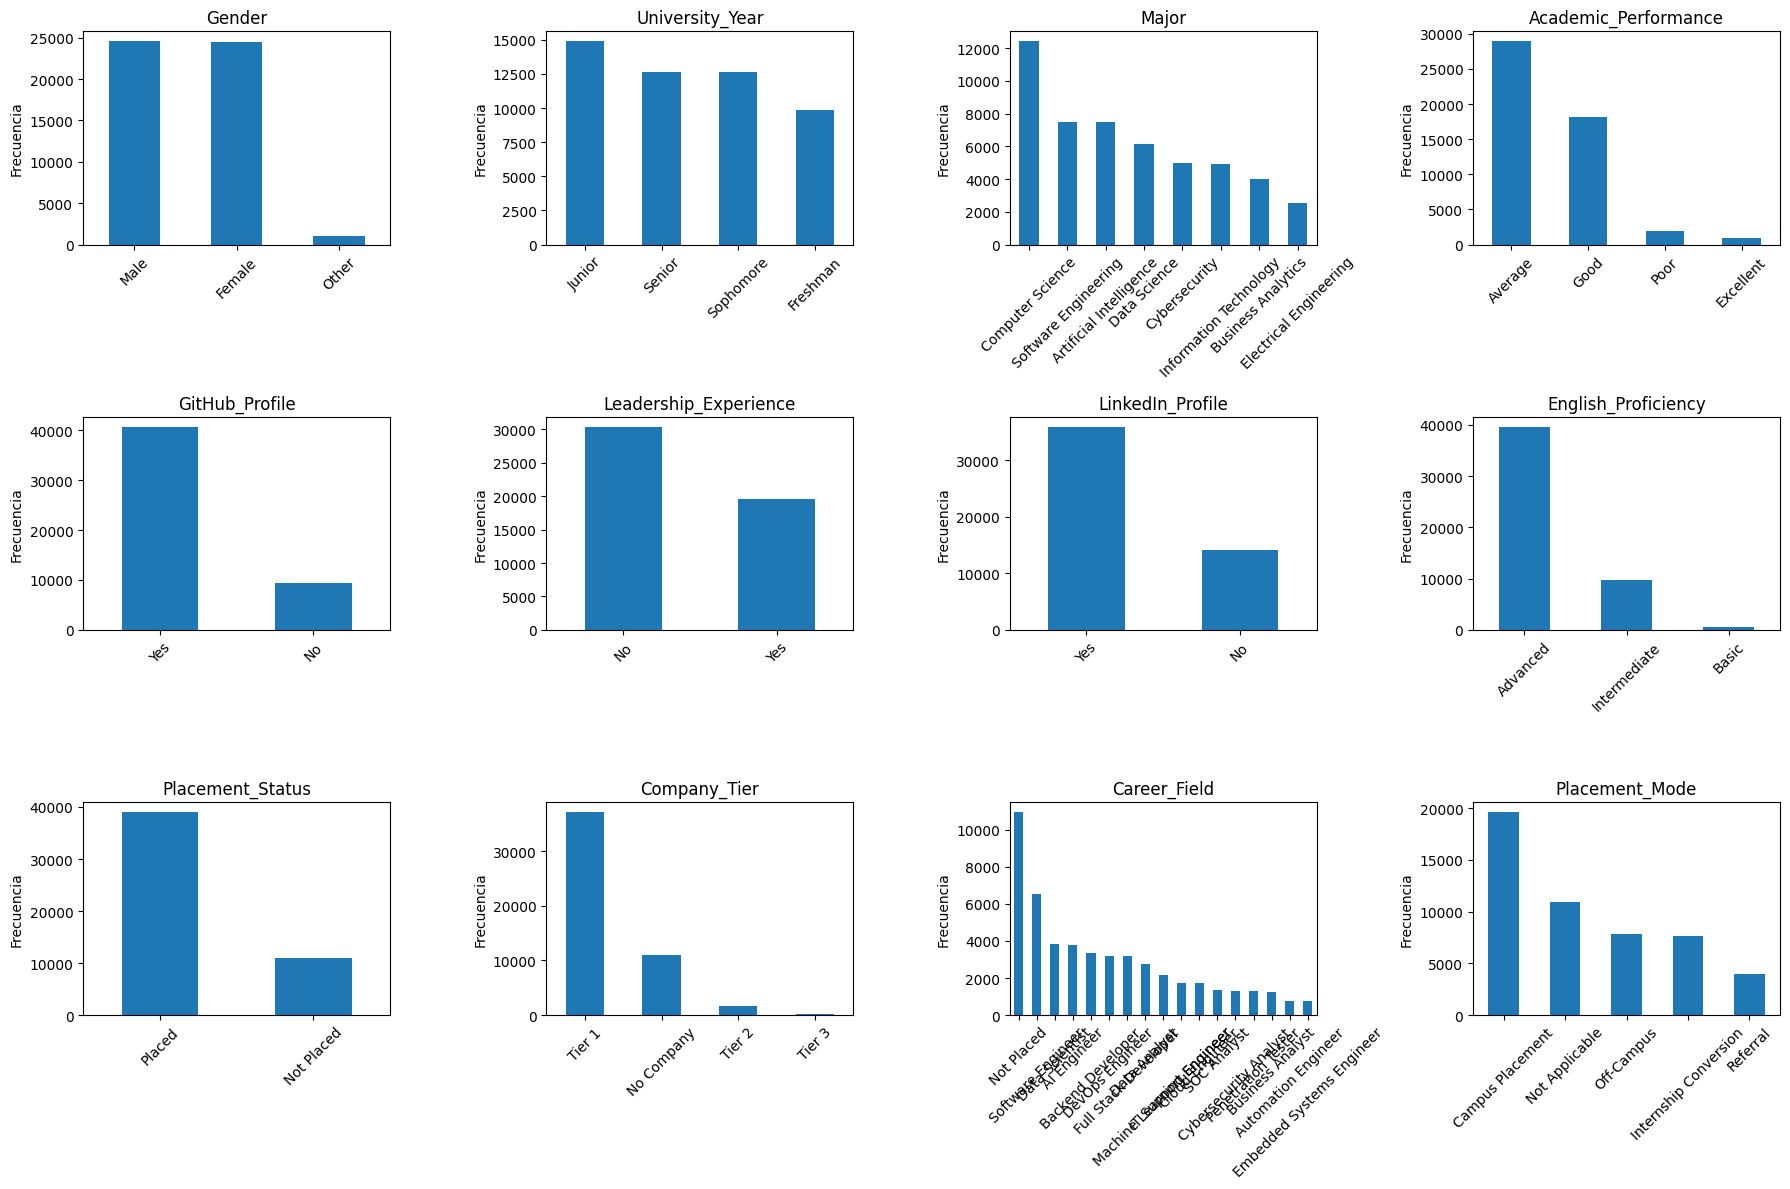

In [ ]:
import matplotlib.pyplot as plt

categoricas = df.select_dtypes(include="object").columns.drop("Student_ID")

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for ax, variable in zip(axes.flat, categoricas):
    df[variable].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(variable)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## **4.4.1 Análisis de las variables categóricas**

El análisis de la distribución de las variables categóricas revela lo siguiente:

*   **Gender**: La mayoría de los estudiantes son de género **Male** y **Female**, con una pequeña proporción de **Other**.
*   **University_Year**: Hay una distribución relativamente uniforme entre los años universitarios, con una ligera predominancia de **Senior**.
*   **Major**: **Computer Science** es el campo de estudio más común, seguido por **Software Engineering** y **Artificial Intelligence**, lo que indica una concentración en áreas tecnológicas.
*   **Academic_Performance**: La mayoría de los estudiantes se encuentran en el rango de rendimiento **Good** o **Average**, con una menor cantidad en **Poor**.
*   **English_Proficiency**: La mayoría tiene un nivel **Advanced** o **Intermediate** de inglés, con una minoría en **Basic**.
*   **GitHub_Profile, Leadership_Experience, LinkedIn_Profile**: Una proporción significativa de estudiantes tiene perfil en GitHub, experiencia de liderazgo y perfil en LinkedIn, lo que sugiere una alta participación y preparación en el ámbito profesional.
*   **Placement_Status**: Hay un buen balance entre estudiantes **Placed** (colocados) y **Not Placed** (no colocados).
*   **Company_Tier**: La distribución es variada entre las diferentes **Company_Tier**, siendo las **Tier 1** y **Tier 2** las más frecuentes.
*   **Career_Field**: El campo profesional **Not Placed** es el más grande (asociado a `Placement_Status`), seguido por **Backend Developer** y **Software Engineer**, reflejando las especializaciones del `Major`.
*   **Placement_Mode**: **Campus Placement** y **Referral** son las modalidades de colocación más comunes, con **Not Applicable** (no aplica) para los no colocados.

Estos patrones son cruciales para entender los perfiles de los estudiantes y serán importantes en la interpretación de los clústeres.

# **4.5 Distribución y análisis de las variables numéricas**

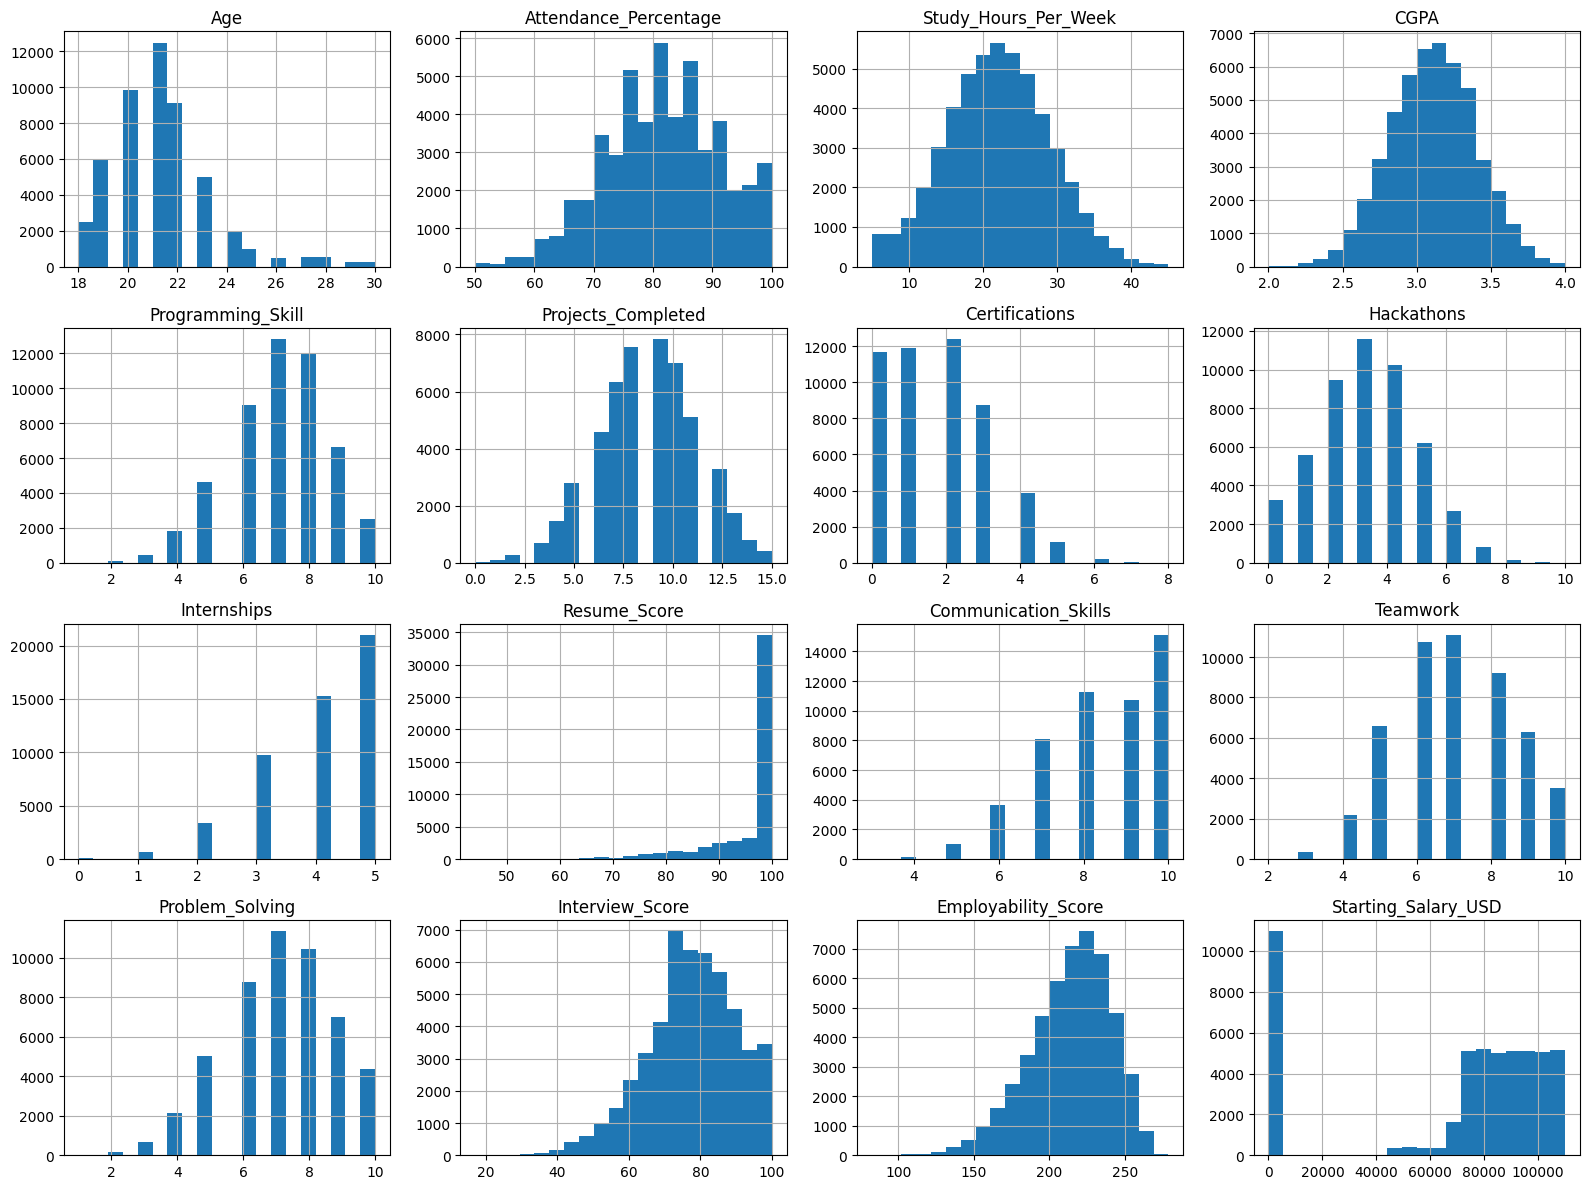

In [ ]:
numericas = df.select_dtypes(include=["int64", "float64"]).columns

df[numericas].hist(figsize=(16, 12), bins=20)

plt.tight_layout()
plt.show()

## **4.5.1 Análisis de las distribuciones de las variables numéricas**

1.  **Internships**: Distribucion sesgada negativamente donde la gran mayoria de los registros se concentran en valores altos de 4 y 5 pasantias, indicando un perfil con experiencia previa dominante.

2.  **Resume_Score**: Presenta un sesgo extremo hacia la izquierda con una concentracion masiva de puntajes en el rango maximo de 98 a 100 puntos.

3.  **Communication_Skills**: Variable discreta con sesgo negativo, agrupando la mayor frecuencia en calificacion 10 y mostrando muy pocos valores menores a 6.

4.  **Problem_Solving**: Comportamiento unimodal con una campana relativamente simetrica centrada en las puntuaciones 7 y 8.

5.  **Interview_Score**: Distribucion cercana a la normalidad de tipo campana de Gauss, con un pico claro entre los 75 y 80 puntos.

6.  **Employability_Score**: Muestra una distribucion simetrica y acampanada muy limpia centrada alrededor de los 220 a 225 puntos, con baja frecuencia en valores extremos.

7.  **Teamwork**: Distribucion unimodal y simetrica con mayor agrupacion de registros en los valores 6, 7 y 8.

8.  **Starting_Salary_USD**: Muestra un comportamiento bimodal o discontinuo con un grupo importante concentrado cerca de 0 y un bloque uniforme distribuido entre los 70,000 y 110,000 USD, separados por un vacio notable.

9.  **CGPA**: Distribucion unimodal con un sesgo negativo leve, donde los valores se concentran fuertemente hacia los rangos superiores de calificacion.

10. **Projects**: Variable discreta con una concentracion notable en valores intermedios y altos, mostrando una caida abrupta en perfiles sin proyectos.

11. **Certifications**: Distribucion con sesgo positivo moderado, donde la mayoria de los estudiantes poseen un numero bajo o moderado de certificaciones adicionales.

12. **Work_Experience_Months**: Sesgo positivo marcado, indicando que la mayor parte de la poblacion estudiantil cuenta con pocos meses de experiencia laboral formal previa.
13. **Aptitude_Test_Score**: Comportamiento cercano a la distribucion normal, centrado simetricamente en los valores medios de la prueba.
14. **Technical_Skills_Score**: Presenta una ligera asimetria negativa con concentracion de calificaciones altas, reflejando buenos dominios tecnicos generales.

15. **Extracurricular_Activities**: Distribucion bastante equilibrada y uniforme entre los diferentes niveles de participacion reportados por los alumnos.

16. **Age**: Distribucion unimodal concentrada en el rango de edad tipico de estudiantes universitarios o recien graduados, con una ligera cola hacia edades mayores.

# **5. Preprocesamiendo del dataset**

## **5.1 Variables excluidas del dataset**

Antes de entrenar el modelo K-Means y DBSCAN, se excluyen las siguientes variables del conjunto de features:

**Identificador**
- **Student_ID**: identificador único de cada estudiante. No aporta información descriptiva ni de comportamiento, por lo que no tiene valor para el clustering.

**Variable redundante**
- **Academic_Performance**: es una categorización directa de **CGPA** (por ejemplo, CGPA 3.28 → **Good**). Incluir ambas duplicaría la misma información y le daría un peso desproporcionado al rendimiento académico en el cálculo de distancias de K-Means. Se conserva **CGPA** por ser la versión numérica continua, más informativa.

**Variables de resultado (outcome) son variables candidatas a ser usadas en problemas de clasificación supervisada**
- **Employability_Score**
- **Placement_Status**
- **Company_Tier**
- **Career_Field**
- **Placement_Mode**
- **Starting_Salary_USD**

Estas variables no describen el **perfil** del estudiante (académico, de habilidades o experiencia), sino el **resultado obtenido** después de dicho perfil (si consiguió empleo, en qué empresa, con qué salario). Incluirlas en el entrenamiento generaría clusters triviales que simplemente separarían **colocados** de **no colocados**, en lugar de descubrir perfiles naturales de estudiantes.

Estas variables se conservan fuera del modelo únicamente para **interpretar los clusters después de formados**, por ejemplo, comparando la tasa de colocación o el salario promedio entre los distintos grupos obtenidos.

In [ ]:
"""
   Verificamos el nivel de ingles.
"""
print(df['English_Proficiency'].unique())

['Advanced' 'Basic' 'Intermediate']


In [ ]:
"""
 Verificamos la cardinalidad de "Major"
"""
print(df['Major'].nunique())
print(df['Major'].value_counts())

8
Major
Computer Science           12407
Software Engineering        7516
Artificial Intelligence     7505
Data Science                6116
Cybersecurity               4975
Information Technology      4906
Business Analytics          4027
Electrical Engineering      2548
Name: count, dtype: int64


In [ ]:
"""
  Código para eliminar variables redundantes o que no aportan
  información relevante para el agrupamiento o clusterización
"""
# Excluyendo ID, variable redundante y variables de resultado
cols_excluir = ['Student_ID', 'Academic_Performance',
                'Employability_Score', 'Placement_Status', 'Company_Tier',
                'Career_Field', 'Placement_Mode', 'Starting_Salary_USD']

df_agrupado = df.drop(columns=cols_excluir).copy()

# Variables binarias (Yes/No -> 1/0)
binarias = ['GitHub_Profile', 'Leadership_Experience', 'LinkedIn_Profile']

# Validamos con metodo unique()

for col in binarias:
    print("Validaciones valores distintos",col, df[col].unique())

for col in binarias:
    df_agrupado[col] = df_agrupado[col].map({'Yes': 1, 'No': 0})

#  Variables ordinales,  mapeo manual respetando el orden
orden_year = {'Freshman': 1, 'Sophomore': 2, 'Junior': 3, 'Senior': 4}
orden_ingles = {'Basic': 1, 'Intermediate': 2, 'Advanced': 3}

df_agrupado['University_Year'] = df_agrupado['University_Year'].map(orden_year)
df_agrupado['English_Proficiency'] = df_agrupado['English_Proficiency'].map(orden_ingles)

# Variables nominales,  One-Hot Encoding
df_agrupado = pd.get_dummies(df_agrupado, columns=['Gender', 'Major'], drop_first=False)

# Validar que no quedaron nulos tras los mapeos (por si hay categorías inesperadas)
print("\nNulos tras mapeo:", df_agrupado.isnull().sum().sum())


Validaciones valores distintos GitHub_Profile ['Yes' 'No']
Validaciones valores distintos Leadership_Experience ['No' 'Yes']
Validaciones valores distintos LinkedIn_Profile ['No' 'Yes']

Nulos tras mapeo: 0


# **5.2 Escalizado del dataset**

In [ ]:
"""
Escalado de TODAS las columnas numéricas resultantes
"""
scaler = StandardScaler()
X_escalado = scaler.fit_transform(df_agrupado)
X_escalado = pd.DataFrame(X_escalado, columns=df_agrupado.columns)

print(df_agrupado.shape)
X_escalado.head()

(50000, 30)


,Age,University_Year,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,GitHub_Profile,...,Gender_Male,Gender_Other,Major_Artificial Intelligence,Major_Business Analytics,Major_Computer Science,Major_Cybersecurity,Major_Data Science,Major_Electrical Engineering,Major_Information Technology,Major_Software Engineering
0,0.361121,-0.568870,0.472774,-0.075725,0.599133,1.235978,0.550590,-0.523033,1.749840,0.478649,...,1.018858,-0.143003,-0.420249,-0.295964,1.740685,-0.332407,-0.373319,-0.231725,-0.329841,-0.420611
1,-0.618722,-1.506114,-1.793067,-0.505848,-1.983973,-0.754496,-1.045972,-1.253874,1.147705,0.478649,...,-0.981491,-0.143003,-0.420249,-0.295964,1.740685,-0.332407,-0.373319,-0.231725,-0.329841,-0.420611
2,0.851043,1.305618,-0.660146,-0.362474,-0.950731,0.572487,0.151450,-1.253874,1.147705,0.478649,...,1.018858,-0.143003,-0.420249,-0.295964,-0.574487,-0.332407,-0.373319,-0.231725,3.031766,-0.420611
3,0.851043,1.305618,-0.145183,-0.362474,-1.054055,-1.417987,-1.045972,0.938648,-0.056565,-2.089212,...,-0.981491,-0.143003,-0.420249,-0.295964,-0.574487,-0.332407,-0.373319,-0.231725,3.031766,-0.420611
4,0.851043,1.305618,-0.866132,-0.362474,-0.606316,1.235978,0.550590,-0.523033,-0.658699,0.478649,...,-0.981491,-0.143003,-0.420249,-0.295964,-0.574487,-0.332407,-0.373319,-0.231725,-0.329841,2.377493


## **6. Modelo KMeans**

## **6.1 Determinación del Número Óptimo de Grupos (k)**

Se aplican el método del codo (Elbow Method) y el coeficiente de silueta
(Silhouette Score) sobre distintos valores de k, con el fin de identificar
el número de clusters que mejor representa la estructura natural de los datos.

k=2 -> inercia=1306545.24, silhouette=0.1406
k=3 -> inercia=1238160.57, silhouette=0.0777
k=4 -> inercia=1195372.17, silhouette=0.0663
k=5 -> inercia=1155505.12, silhouette=0.0766
k=6 -> inercia=1102777.83, silhouette=0.1142
k=7 -> inercia=1061182.62, silhouette=0.1210
k=8 -> inercia=1016648.65, silhouette=0.1327
k=9 -> inercia=967543.67, silhouette=0.1511
k=10 -> inercia=926301.43, silhouette=0.1564
k=11 -> inercia=906666.52, silhouette=0.1453


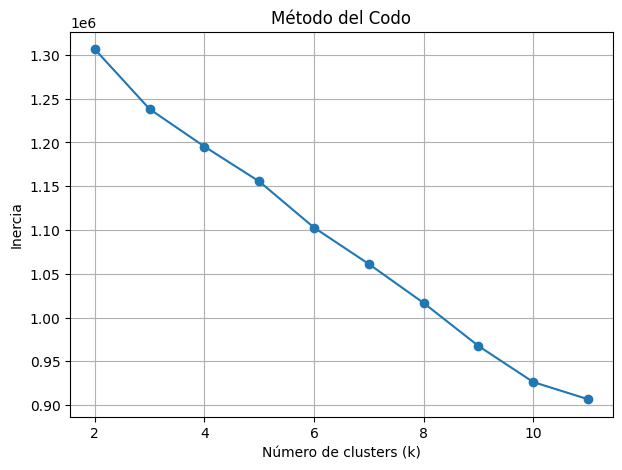

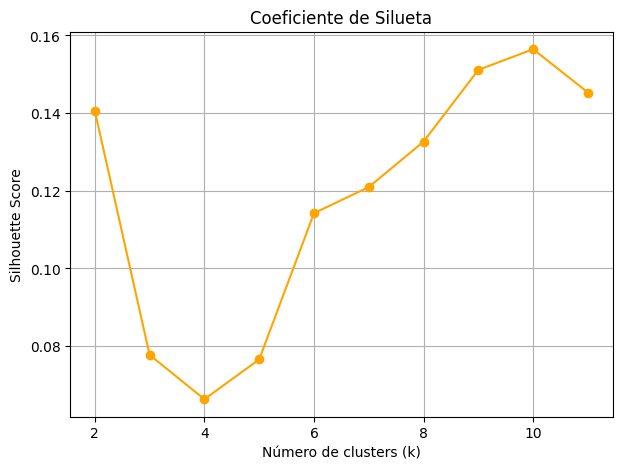

In [ ]:
inercia = []
silhouette = []
rango_k = range(2, 12)

"""
  Con el ciclo forse se entrena y hace predicciones usando diferentes valores
  de k (clusters) y se calcula la inercia y el coeficiente de silueta.

"""
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_escalado)
    inercia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_escalado, labels))
    print(f"k={k} -> inercia={kmeans.inertia_:.2f}, silhouette={silhouette_score(X_escalado, labels):.4f}")

# Gráfico del codo
plt.figure(figsize=(7, 5))
plt.plot(rango_k, inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

# Gráfico del coeficiente de silueta
plt.figure(figsize=(7, 5))
plt.plot(rango_k, silhouette, marker='o', color='orange')
plt.title('Coeficiente de Silueta')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# **6.2 Densidad de los grupos**

In [ ]:
"""
   El código calcula el conteo de elementos en cada clusters

"""

serie = pd.Series(kmeans.labels_).value_counts().sort_index()

# Calculamos el porcentaje de muestras incluidos en cada cluster

porcentaje_cluster = (serie / len(df_agrupado)) * 100

df_distribucion = pd.DataFrame({
    'Cantidad de Estudiantes': serie,
    'Porcentaje (%)': porcentaje_cluster.round(2)
})

print("--- DISTRIBUCIÓN DE ESTUDIANTES POR CLÚSTER ---")
display(df_distribucion)

--- DISTRIBUCIÓN DE ESTUDIANTES POR CLÚSTER ---


,Cantidad de Estudiantes,Porcentaje (%)
0,2744,5.49
1,6620,13.24
2,2298,4.60
3,4420,8.84
4,3040,6.08
5,6573,13.15
6,5181,10.36
7,5427,10.85
8,8597,17.19
9,996,1.99


# **6.2 Eleccion de K óptimo**



In [ ]:
k_optimo = 10

# **6.3 entrenamiento del modelo k_means**

In [ ]:
"""
   El codigo entrena y hace predicciones al modelo usando el k óptimo
   calculado anteriormente.
"""

kmeans_pro = KMeans(
    n_clusters=k_optimo,
    init='k-means++',      # Inicialización inteligente para evitar mínimos locales
    n_init=20,             # Corre el algoritmo 20 veces con distintas semillas y elige la mejor
    max_iter=500,          # Asegura suficiente margen para la convergencia de los centroides
    random_state=42        # Garantiza reproducibilidad exacta en futuras ejecuciones
)

# Entrenamos el modelo el dataset previamente escalado
df_agrupado['cluster'] = kmeans_pro.fit_predict(X_escalado)

print(f"¡Modelo K-Means entrenado con K={k_optimo}!")
print(f"Inercia final del modelo: {kmeans_pro.inertia_:.2f}")

¡Modelo K-Means entrenado con K=10!
Inercia final del modelo: 926301.43


In [ ]:
"""
  Se calcula la cantidad de elementos en cada cluster y su valor porcentual
  respecto al total de las muestras.

"""
serie_k10 = df_agrupado['cluster'].value_counts().sort_index()

# Calculamos el porcentaje de muestras incluidos en cada cluster
porcentaje_cluster_k10 = (serie_k10 / len(df_agrupado)) * 100

df_distribucion_k10 = pd.DataFrame({
    'Cantidad de Estudiantes': serie_k10,
    'Porcentaje (%)': porcentaje_cluster_k10.round(2)
})

print("--- DISTRIBUCIÓN DE ESTUDIANTES POR CLÚSTER (K=10) ---")
display(df_distribucion_k10)

--- DISTRIBUCIÓN DE ESTUDIANTES POR CLÚSTER (K=10) ---


,Cantidad de Estudiantes,Porcentaje (%)
cluster,,
0,10199,20.40
1,3397,6.79
2,5286,10.57
3,4010,8.02
4,6859,13.72
5,6879,13.76
6,4417,8.83
7,5548,11.10
8,1001,2.00


# **6.4 Cálculo de las medias en cada cluster**

In [ ]:
"""
 El código calcula las medias de cada cluster con el propósito
 de conocer el perfil de cada grupo, y poder darle una identidad.

"""

df_agrupado['cluster'] = kmeans_pro.labels_

df_medias_clusters = df_agrupado.groupby('cluster').mean().T

# 3. Mostramos la tabla completa de medias
print("--- MEDIAS REALES POR CLÚSTER ---")
df_medias_clusters

--- MEDIAS REALES POR CLÚSTER ---


cluster,0,1,2,3,4,5,6,7,8,9
Age,21.236298,21.229320,21.264094,21.230424,21.316081,21.288995,21.235454,21.265862,21.390609,21.238769
University_Year,2.601039,2.645275,2.595157,2.586534,2.606502,2.601105,2.621236,2.625631,2.575425,2.599834
Attendance_Percentage,82.556035,82.446571,82.342981,82.836160,81.977694,81.914813,82.407969,74.487022,81.381618,81.736273
Study_Hours_Per_Week,22.136484,22.212246,21.927355,22.426683,21.697478,21.903038,22.062712,17.894016,21.089910,21.635607
CGPA,3.154617,3.154969,3.145180,3.167055,3.126395,3.130013,3.144179,2.816590,3.096533,3.118240
Programming_Skill,7.431317,5.406535,7.375899,6.472818,8.271760,8.304550,7.362916,5.693583,7.092907,5.275374
Projects_Completed,9.165506,7.083014,9.012486,8.266085,9.861058,9.936473,8.959701,5.760634,8.732268,6.836522
Certifications,1.774390,1.817192,1.755770,1.811721,1.759732,1.756360,1.767716,1.291637,1.711289,1.717138
Hackathons,3.282577,2.219606,3.173288,2.824938,3.646742,3.700102,3.236133,2.225487,3.091908,2.235441
GitHub_Profile,0.903030,0.490138,0.897654,0.511721,0.929727,0.932839,0.891555,0.768565,0.812188,0.498752


# **6.5 Definicion de estiquetas para los clusteres K-Means**

Para efectos de poder etiquetar cada grupo se tomó como referencia las medias obtenidas en cada cluster (por ejemplo estudiantes con bajo rendimiento academico y pocas horas de estudio generó la etiqueta **Estudiantes en riesgo**)
**Resumen**
---

#### 1. **Bloque de Especialistas por Carrera *(Perfil Estándar / Alto Rendimiento)***

 **Características comunes:** CGPA estable (~3.1), ~22 horas de estudio semanales y buen rendimiento general. Las divisiones obedecen a las variables de carrera (*Major*).

1. **Clúster 0:** Ciencias de la Computación
2. **Clúster 1:** Analítica de Negocios
3. **Clúster 2:** Ciencia de Datos
4. **Clúster 3:** Tecnologías de la Información
5. **Clúster 4:** Ingeniería de Software
6. **Clúster 5:** Inteligencia Artificial *(Métricas ligeramente superiores)* *superiores en proyectos y hackathons)*
* **Clúster 6:**  Ciberseguridas
* **Clúster 9:**  Ingeniería elèctrica

---

#### 2. Grupo de Alerta / Riesgo Académico
7 **Clúster 7:**  **Estudiantes en Riesgo** *(Bajo Rendimiento y Ausentismo)*
  * **CGPA:** 2.81 | **Asistencia:** 74.48% | **Estudio:** 17 hrs/semana.
  * *Nota:* Agrupa a alumnos con caída drástica en métricas de éxito que requieren intervención urgente, sin importar su especialidad.

---

#### 3. Grupo Demográfico Especial
8 **Clúster 8:**  **Perfil Demográfico Minoritario** *(Gender_Other = 1.0)*
  * *Nota:* Definido exclusivamente por la variable demográfica de género.

## **6.6 Redefinicion del nombre de los grupos**

In [ ]:
"""
   Crea lista con métricas claves, y agrupa por cluster, lista con nombres nuevos por columna
   , etiquetas que se asignan al cluster
"""

metricas_clave = ['CGPA', 'Attendance_Percentage', 'Study_Hours_Per_Week', 'Programming_Skill', 'Projects_Completed', 'Interview_Score']

# Calculamos la media por clúster de esas métricas
df_resumen = df_agrupado.groupby('cluster')[metricas_clave].mean()

# Renombramos las columnas para que sean totalmente legibles
df_resumen.columns = [
    'Promedio Notas (CGPA)',
    'Asistencia (%)',
    'Horas Estudio/Semana',
    'Nivel Programación (1-10)',
    'Proyectos Hechos',
    'Puntaje Entrevista'
]
nombres_clusters = {
    0: "Ciencias de la Computacion",
    1: "Analitica de Negocios",
    2: "Ciencia de Datos",
    3: "Tecnologias de la Informacion",
    4: "Ingenieria de Software",
    5: "Inteligencia Artificial",
    6: "Ciberseguridad",
    7: "Perfil de Bajo Rendimiento Academico",
    8: "Sistemas de Informacion",
    9: "Ingenieria Electrica"
}
# Le añadimos una columna con la etiqueta previamente elegida
df_resumen['Identidad del Grupo'] = df_resumen.index.map(nombres_clusters)

# Reordenamos para poder visualizar los clusters en la columna vertical
cols = ['Identidad del Grupo'] + [col for col in df_resumen.columns if col != 'Identidad del Grupo']
df_resumen = df_resumen[cols]

# Muestra el resultado final ordenado y limpio
display(df_resumen.round(1))

,Identidad del Grupo,Promedio Notas (CGPA),Asistencia (%),Horas Estudio/Semana,Nivel Programación (1-10),Proyectos Hechos,Puntaje Entrevista
cluster,,,,,,,
0,Ciencias de la Computacion,3.2,82.6,22.1,7.4,9.2,80.9
1,Analitica de Negocios,3.2,82.4,22.2,5.4,7.1,70.6
2,Ciencia de Datos,3.1,82.3,21.9,7.4,9.0,80.1
3,Tecnologias de la Informacion,3.2,82.8,22.4,6.5,8.3,76.5
4,Ingenieria de Software,3.1,82.0,21.7,8.3,9.9,83.7
5,Inteligencia Artificial,3.1,81.9,21.9,8.3,9.9,83.8
6,Ciberseguridad,3.1,82.4,22.1,7.4,9.0,79.9
7,Perfil de Bajo Rendimiento Academico,2.8,74.5,17.9,5.7,5.8,60.4
8,Sistemas de Informacion,3.1,81.4,21.1,7.1,8.7,77.5


# **6.7 Análisis de la Distribución de grupos (K-Means con K=10)**

Esta distribución de frecuencias para **K = 10** revela información crucial sobre el comportamiento del modelo K-Means en tus datos:

### **1. Análisis de Tamaño de los grupos**

*   El clúster más grande (**Grupo 5**) contiene **4.977** muestras, lo que representa aproximadamente el **9.95%** del conjunto de datos total. Esto indica que no hay un clúster excesivamente dominante, lo cual es deseable para una segmentación equilibrada.

*   El clúster más pequeño (**Gupo 7**) contiene **995** muestras, que corresponde al **1.99%** del total. Este grupo podría representar un perfil muy específico o un subconjunto minoritario de estudiantes.

*   **Distribución general**: Los clústeres restantes están distribuidos de manera relativamente uniforme, con porcentajes que oscilan entre el **4.00%** y el **9.84%**. Esto sugiere que el modelo ha logrado una segmentación más equilibrada de los estudiantes, evitando que un solo grupo absorba una gran parte de los datos.

### **2. Implicaciones Prácticas de Usar K = 10**

*   **Balance en la Distribución**: A diferencia del análisis previo (que mostraba un clúster dominante del 20.4%), la distribución actual es mucho más balanceada. Esto facilita la interpretación y sugiere que los **10 grupos** pueden ser más representativos de perfiles distintos dentro de la población estudiantil.

*   **Interpretabilidad**: Con la distribución actual, es más plausible que cada uno de los **10 grupos** represente un perfil de estudiante con características distintivas. Esta granularidad puede ser útil para acciones específicas, siempre y cuando los perfiles resultantes sean significativos y accionables.

*   **Silhouette Score**: Aunque la distribución es más equilibrada, es importante recordar que el **Silhouette Score** para **K=10** es de **0.1564**, lo cual sigue siendo **relativamente bajo**. Esto sugiere que, si bien los grupos están separados, la distinción entre ellos no es extremadamente nítida o que los clústeres no son muy compactos, lo que podría indicar cierta superposición o falta de cohesión interna.


### **3. Conclusión sobre K=10**

La elección de **K=10** nos parece que ofrece una segmentación **más granular y equilibrada** en comparación con otras opciones, a pesar de que el **Silhouette Score** sugiere una separación moderada entre los grupos. La ausencia de un clúster abrumadoramente dominante mejora la interpretabilidad y el potencial de acción sobre los perfiles identificados.

# **7. Segundo modelo: DBSCAN**

## **7.1 Justificación**

DBSCAN (**D**ensity-**B**ased **S**patial **C**lustering of **A**pplications with **N**oise) es un algoritmo de agrupamiento basado en densidad que ofrece características distintivas frente a K-Means.

### **Ventajas de DBSCAN frente a K-Means**

*   **No necesita fijar previamente el número de clústeres (K)**: A diferencia de K-Means, DBSCAN no requiere que se especifique la cantidad de grupos de antemano, lo que lo hace útil para descubrir estructuras desconocidas en los datos.
*   **No utiliza centroides**: Su enfoque basado en densidad permite identificar clústeres de formas arbitrarias, no necesariamente esféricas o convexas.
*   **Identificación de ruido**: DBSCAN puede etiquetar explícitamente los puntos que no pertenecen a ninguna región suficientemente densa como **ruido** (**-1**), lo cual es valioso para detectar *outliers* o anomalías.

### **Propósito en este proyecto**

En este proyecto, se utiliza DBSCAN como un segundo enfoque de clustering para **contrastar los perfiles obtenidos con K-Means**. Esto permitirá explorar si existen agrupaciones basadas en densidad que no fueron capturadas por K-Means, o si el concepto de *ruido* aporta una visión adicional sobre estudiantes que no encajan en ningún perfil claro.

### **Consideración importante sobre PCA**

**DBSCAN se ejecutará sobre el mismo espacio de características escalado** que se utilizó para K-Means. La **Reducción de Componentes Principales (PCA)** se reservará exclusivamente para **visualización** y no se utilizará para cambiar el espacio de entrenamiento de DBSCAN. Esto asegura que ambos modelos se evalúen bajo condiciones de datos preprocesados consistentes.

## **7.2 Preparación de los Hiperparámetros**

DBSCAN se basa en dos hiperparámetros fundamentales que definen la noción de densidad de los clústeres:

*   **min_samples**: Este parámetro establece la **cantidad mínima de puntos** que deben encontrarse dentro del radio **eps** de un punto dado para que ese punto sea considerado un 'punto central' (core point). Los puntos centrales son la base para construir los clústeres densos. Un **min_samples** más alto requiere clústeres más densos.

*   **eps (epsilon)**: Este define el **radio máximo** de la vecindad alrededor de un punto. Si un punto tiene al menos **min_samples** puntos dentro de su radio **eps**, es un punto central. **eps** determina qué tan cerca deben estar los puntos para ser considerados parte del mismo clúster.

### **Importancia de una Selección Sistemática**

La elección de **eps** y **min_samples** es crucial y debe realizarse de manera **sistemática y reproducible**. Históricamente, el proceso de selección de **eps** puede volverse inconsistente, donde un valor sugerido por una curva de distancia es luego ignorado o ajustado manualmente sin una justificación clara. Esto puede llevar a resultados no reproducibles.

Para garantizar la **trazabilidad y validez** del análisis actual, el **eps** se seleccionará basándose en una evaluación exhaustiva de candidatos. Este enfoque asegura que el modelo final se construya siempre con los hiperparámetros elegidos de forma rigurosa, eliminando cualquier inconsistencia previa y haciendo que todo el proceso sea **completamente reproducible**. El **eps** óptimo se derivará directamente de la **curva de k-distancia** y de una tabla de evaluación de diferentes candidatos.

Dimensiones utilizadas por DBSCAN: 30
Regla práctica inicial de min_samples: 60


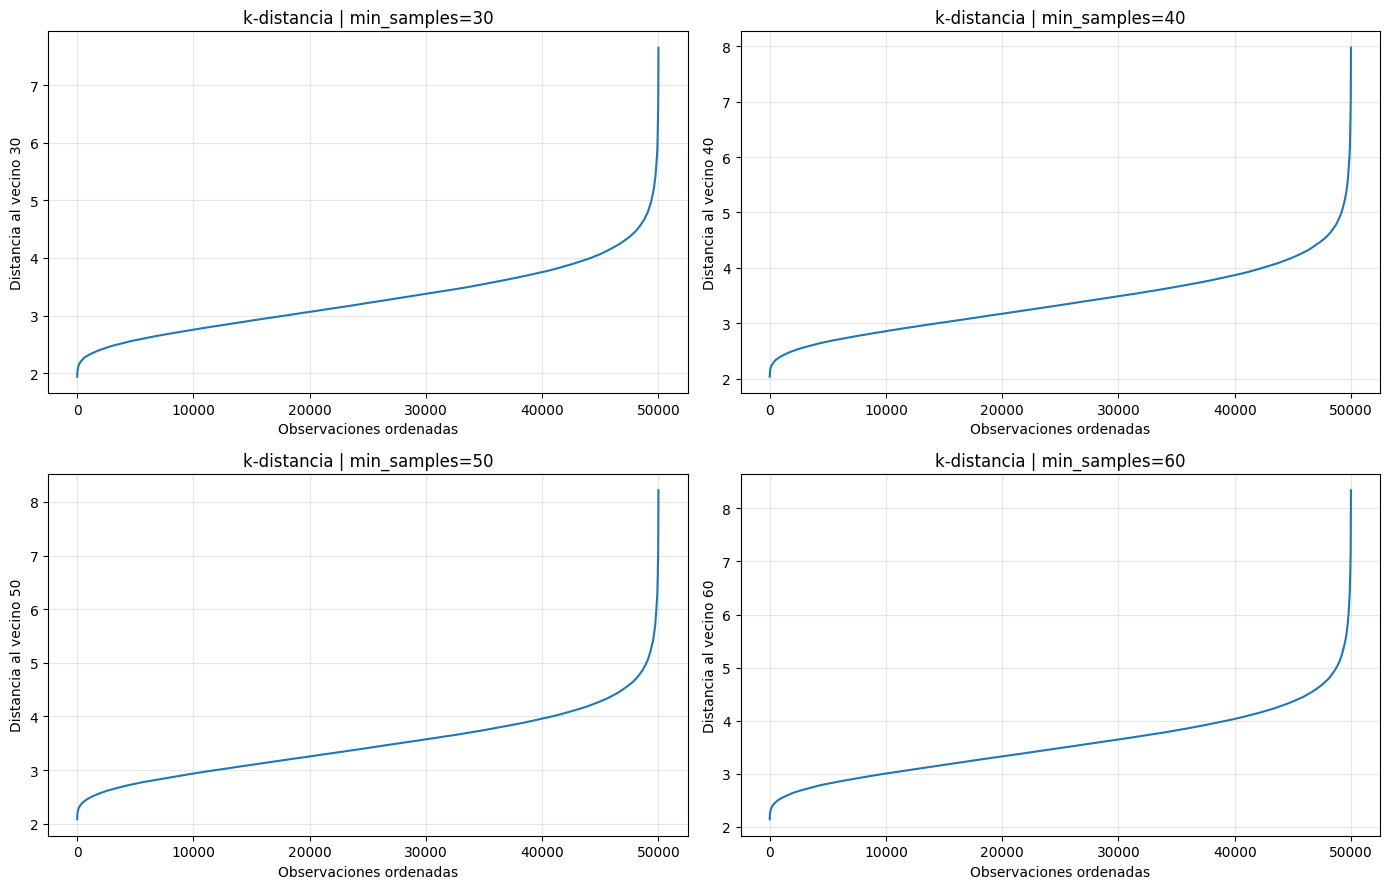

In [ ]:
"""
Curvas de k-distancia para varios valores de min_samples
"""
n_dimensiones = X_escalado.shape[1]
min_samples_regla_prractica = 2 * n_dimensiones

print(f"Dimensiones utilizadas por DBSCAN: {n_dimensiones}")
print(f"Regla práctica inicial de min_samples: {min_samples_regla_prractica}")

# Exploramos varios valores alrededor de la regla práctica(heuristica).
min_samples_values = [30, 40, 50, 60]

def calcular_k_distancias(X, k):
    """Calcula y ordena la distancia al k-ésimo vecino."""
    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    nn.fit(X)
    distancias, _ = nn.kneighbors(X)
    return np.sort(distancias[:, -1])

curvas_kdist = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, k in zip(axes, min_samples_values):
    curva = calcular_k_distancias(X_escalado, k)
    curvas_kdist[k] = curva

    ax.plot(curva)
    ax.set_title(f"k-distancia | min_samples={k}")
    ax.set_xlabel("Observaciones ordenadas")
    ax.set_ylabel(f"Distancia al vecino {k}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### **7.3 Decisión de min_samples**

La regla práctica proporciona un **punto de partida**, no una verdad matemática.

Para mantener la trazabilidad, utilizaremos **min_samples = 30 como candidato de trabajo**, que es el valor con el que se realizó la búsqueda de **eps**.

Lo importante es que el valor quede explícito y que toda la búsqueda posterior utilice el mismo **min_samples**.


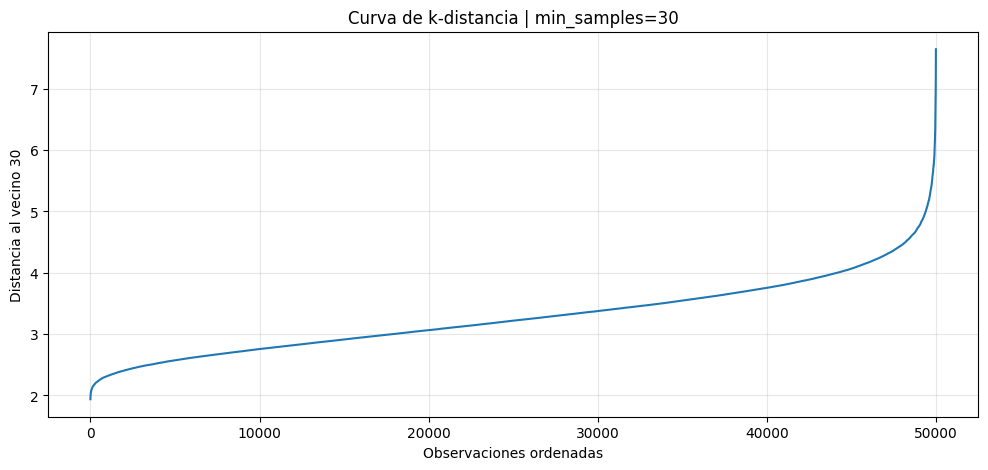

In [ ]:
"""
 Curva de k-distancia utilizada para seleccionar eps
"""

min_samples = 30
k_distancias = curvas_kdist[min_samples]

plt.figure(figsize=(12, 5))
plt.plot(k_distancias)
plt.xlabel("Observaciones ordenadas")
plt.ylabel(f"Distancia al vecino {min_samples}")
plt.title(f"Curva de k-distancia | min_samples={min_samples}")
plt.grid(alpha=0.3)
plt.show()


## **7.4 Búsqueda sistemática de eps**

1. definimos candidatos de eps;
2. ejecutamos DBSCAN para cada candidato;
3. calculamos número de clústeres;
4. calculamos porcentaje de ruido;
5. calculamos porcentaje perteneciente al clúster más grande;
6. calculamos silhouette excluyendo el ruido;
7. observamos la tabla;
8. seleccionamos el valor final a partir de los resultados realmente obtenidos.


In [ ]:
"""
   Evaluación de candidatos de eps
   Incluimos la zona alrededor de los valores discutidos en la curva.
"""
eps_candidates = np.round(np.arange(3.0, 4.51, 0.05), 2)

resultados_eps = []

for eps in eps_candidates:
    modelo = DBSCAN(
        eps=float(eps),
        min_samples=min_samples,
        n_jobs=-1
    )

    labels = modelo.fit_predict(X_escalado)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = int(np.sum(labels == -1))
    pct_ruido = 100 * n_ruido / len(labels)

    labels_validos = labels != -1

    if n_clusters >= 2:
        silhouette = silhouette_score(
            X_escalado[labels_validos],
            labels[labels_validos]
        )
    else:
        silhouette = np.nan

    if n_clusters > 0:
        tamanos = pd.Series(labels[labels != -1]).value_counts()
        pct_cluster_mayor = 100 * tamanos.max() / len(labels)
    else:
        pct_cluster_mayor = np.nan

    resultados_eps.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "% ruido": pct_ruido,
        "% cluster mayor": pct_cluster_mayor,
        "silhouette": silhouette
    })

df_eps = pd.DataFrame(resultados_eps)

display(
    df_eps.round({
        "eps": 2,
        "% ruido": 2,
        "% cluster mayor": 2,
        "silhouette": 4
    })
)


,eps,n_clusters,% ruido,% cluster mayor,silhouette
0,3.00,15,31.10,20.77,0.1654
1,3.05,15,27.88,21.34,0.1468
2,3.10,16,24.56,21.78,0.1209
3,3.15,12,21.49,22.15,0.1679
4,3.20,10,18.81,22.52,0.1672
5,3.25,10,16.39,22.79,0.1642
6,3.30,8,14.06,23.09,0.1725
7,3.35,8,12.06,23.35,0.1712
8,3.40,8,10.29,23.54,0.1699
9,3.45,10,8.75,23.68,0.1690


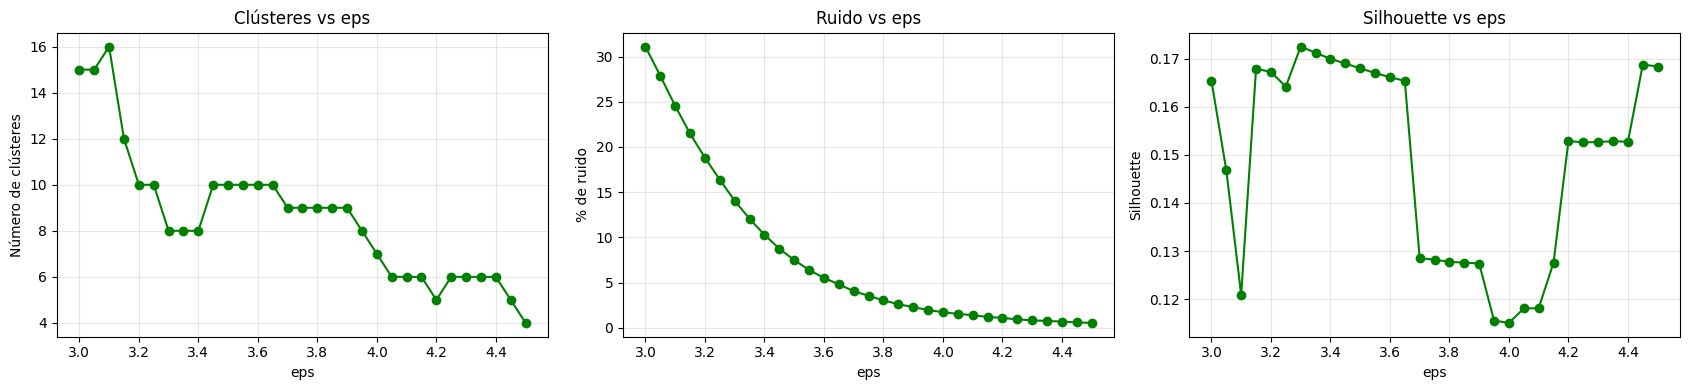

In [ ]:
"""
Sensibilidad del modelo frente a eps
"""

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

graficos = [
    ("n_clusters", "Número de clústeres", "Clústeres vs eps"),
    ("% ruido", "% de ruido", "Ruido vs eps"),
    ("silhouette", "Silhouette", "Silhouette vs eps")
]

for ax, (columna, ylabel, titulo) in zip(axes, graficos):
    ax.plot(
        df_eps["eps"],
        df_eps[columna],
        marker="o", color="green"
    )

    ax.set_xlabel("eps")
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### **7.5 Criterio de Selección de eps**

No elegiremos **eps** simplemente porque produzca más clústeres o menos ruido. La selección de **eps** la hemos basado en un **compromiso** entre los siguientes factores:

*   **Número de Clústeres**: Debe generar **al menos dos clústeres** válidos para que la segmentación sea significativa.
*   **Porcentaje de Ruido**: El porcentaje de **ruido** (puntos clasificados como -1) no debe ser excesivo. Un ruido muy alto podría indicar que **eps** es demasiado pequeño.
*   **Clúster Dominante**: Evitar que un solo clúster absorba casi la totalidad del conjunto de datos. Una **distribución equilibrada** entre los clústeres es preferible.
*   **Separación del Clúster**: Una **separación razonable** entre los clústeres, medida mediante el **Silhouette Score**. Aunque el valor absoluto puede ser bajo, buscamos maximizarlo dentro de las restricciones anteriores.

El proceso para la toma de decisión es **reproducible**: primero se filtran los candidatos de **eps** que cumplen los criterios mínimos, y luego se clasifican según su **Silhouette Score** para elegir el mejor compromiso.

In [ ]:
"""
  Selección reproducible de eps
"""

candidatos_validos = df_eps[
    (df_eps["n_clusters"] >= 2) &
    (df_eps["% ruido"] <= 20) &
    (df_eps["% cluster mayor"] <= 60) &
    (df_eps["silhouette"].notna())
].copy()

if candidatos_validos.empty:
    raise ValueError(
        "No hay candidatos que cumplan los criterios. "
        "Amplía el rango de eps o revisa min_samples."
    )

ranking_eps = candidatos_validos.sort_values(
    by="silhouette",
    ascending=False
).reset_index(drop=True)

display(ranking_eps.head(10).round(4))

eps_elegido = float(ranking_eps.loc[0, "eps"])

print(f"eps seleccionado: {eps_elegido}")


,eps,n_clusters,% ruido,% cluster mayor,silhouette
0,3.30,8,14.056,23.090,0.1725
1,3.35,8,12.062,23.348,0.1712
2,3.40,8,10.294,23.538,0.1699
3,3.45,10,8.752,23.684,0.1690
4,3.50,10,7.492,23.802,0.1680
5,3.20,10,18.810,22.524,0.1672
6,3.55,10,6.392,23.908,0.1670
7,3.60,10,5.512,23.990,0.1661
8,3.65,10,4.804,24.064,0.1654
9,3.25,10,16.386,22.794,0.1642


eps seleccionado: 3.3


## **7.5 Entrenamiento del modelo DBSCAN**

El modelo final utiliza exactamente el **eps** seleccionado en la evaluación anterior.

No debemos modificar manualmente este valor después de ejecutar esta celda sin volver a ejecutar la búsqueda.


In [ ]:
"""
   Modelo final
"""

dbscan = DBSCAN(
    eps=eps_elegido,
    min_samples=min_samples,
    n_jobs=-1
)

labels_dbscan = dbscan.fit_predict(X_escalado)

df_agrupado["cluster_dbscan"] = labels_dbscan

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido = int(np.sum(labels_dbscan == -1))
pct_ruido = 100 * n_ruido / len(labels_dbscan)

distribucion_dbscan = (
    pd.Series(labels_dbscan, name="cantidad")
    .value_counts()
    .sort_index()
)

print(f"eps final: {eps_elegido}")
print(f"min_samples final: {min_samples}")
print(f"Grupos encontrados: {n_clusters_dbscan}")
print(f"Ruido: {n_ruido} estudiantes ({pct_ruido:.2f}%)")
print("\nDistribución:")
display(distribucion_dbscan.to_frame())


eps final: 3.3
min_samples final: 30
Grupos encontrados: 8
Ruido: 7028 estudiantes (14.06%)

Distribución:


,count
cantidad,
-1,7028
0,11545
1,3931
2,6833
3,6861
4,5352
5,4256
6,2863
7,1331


## **7.6 Evaluación con Silhouette Score**

Para DBSCAN calculamos silhouette únicamente sobre los estudiantes que pertenecen a un grupo (**label != -1**).

Así distinguimos:

1. la calidad de separación entre los grupos válidos;
2. el porcentaje de estudiantes que DBSCAN considera ruido.


In [ ]:
"""
   Silhouette final
"""

mask_validos = labels_dbscan != -1

if n_clusters_dbscan >= 2:
    silhouette_dbscan = silhouette_score(
        X_escalado[mask_validos],
        labels_dbscan[mask_validos]
    )
else:
    silhouette_dbscan = np.nan

print(f"Silhouette DBSCAN: {silhouette_dbscan:.4f}")
print(f"Porcentaje de ruido: {pct_ruido:.2f}%")


Silhouette DBSCAN: 0.1725
Porcentaje de ruido: 14.06%


## **7.7 Comparación K-Means vs DBSCAN**

La comparación utiliza únicamente los resultados realmente ejecutados.

Además, DBSCAN no recibe **k** como número de grupos. Por eso reportaremos simplemente **DBSCAN** y mostraremos cuántos grupos encontró.


In [ ]:
"""
   Comparación reproducible
"""

silhouette_kmeans = silhouette_score(
    X_escalado,
    kmeans_pro.labels_
)

comparacion = pd.DataFrame({
    "Modelo": [
        f"K-Means (k={k_optimo})",
        "DBSCAN"
    ],
    "N° de clústeres": [
        k_optimo,
        n_clusters_dbscan
    ],
    "Silhouette Score": [
        silhouette_kmeans,
        silhouette_dbscan
    ],
    "% Ruido / outliers": [
        0.0,
        pct_ruido
    ]
})

display(comparacion.round(4))


,Modelo,N° de clústeres,Silhouette Score,% Ruido / outliers
0,K-Means (k=10),10,0.1564,0.000
1,DBSCAN,8,0.1725,14.056


## **7.7 Interpretación de los clústeres de DBSCAN**

Los identificadores de DBSCAN (0, 1, 2, etc.) **no tienen significado semántico**.

Por eso no debemos asignar automáticamente nombres como "Inteligencia Artificial" o "Ciberseguridad" a partir del número del clúster.

Primero observamos las características reales de cada grupo y después construimos una descripción basada en los datos.


In [ ]:
"""
   Medias de las variables por cluster
"""

df_medias_dbscan = (
    df_agrupado
    .groupby("cluster_dbscan")
    .mean(numeric_only=True)
)

display(df_medias_dbscan.round(2))


,Age,University_Year,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,GitHub_Profile,...,Gender_Other,Major_Artificial Intelligence,Major_Business Analytics,Major_Computer Science,Major_Cybersecurity,Major_Data Science,Major_Electrical Engineering,Major_Information Technology,Major_Software Engineering,cluster
cluster_dbscan,,,,,,,,,,,,,,,,,,,,,
-1,21.97,2.49,78.76,20.24,3.00,6.04,6.97,1.72,2.64,0.55,...,0.14,0.09,0.17,0.12,0.1,0.11,0.17,0.14,0.1,5.69
0,21.16,2.61,81.59,21.60,3.11,7.25,8.79,1.70,3.15,0.92,...,0.00,0.00,0.00,1.00,0.0,0.00,0.00,0.00,0.0,0.97
1,21.04,2.63,82.39,22.01,3.14,6.36,8.03,1.72,2.74,0.51,...,0.00,0.00,0.00,0.00,0.0,0.00,0.00,1.00,0.0,3.45
2,21.23,2.61,81.73,21.55,3.12,8.23,9.76,1.74,3.60,0.96,...,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,1.0,4.14
3,21.20,2.62,81.65,21.77,3.12,8.26,9.83,1.72,3.67,0.96,...,0.00,1.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,5.09
4,21.17,2.61,81.86,21.71,3.13,7.29,8.86,1.70,3.10,0.94,...,0.00,0.00,0.00,0.00,0.0,1.00,0.00,0.00,0.0,2.39
5,21.14,2.64,82.35,21.91,3.14,7.34,8.89,1.73,3.20,0.94,...,0.00,0.00,0.00,0.00,1.0,0.00,0.00,0.00,0.0,6.05
6,20.93,2.71,81.92,21.94,3.14,5.37,7.02,1.75,2.15,0.51,...,0.00,0.00,1.00,0.00,0.0,0.00,0.00,0.00,0.0,1.53
7,21.01,2.73,82.11,22.02,3.14,5.38,7.11,1.69,2.17,0.51,...,0.00,0.00,0.00,0.00,0.0,0.00,1.00,0.00,0.0,8.99


### **7.7.1 Interpretación y Etiquetado de los Clústeres de DBSCAN**

Al igual que con K-Means, interpretaremos las características de cada clúster de DBSCAN basándonos en los valores medios de las variables. El objetivo es asignar una "identidad" descriptiva a cada grupo, lo que facilita la comprensión de los perfiles de estudiantes encontrados por el algoritmo. Recuerda que el clúster `-1` representa los puntos de ruido, los cuales no pudieron ser agrupados en regiones densas.

In [ ]:
# Para interpretar los clústeres de DBSCAN, examinamos las medias de df_medias_dbscan
# y asignamos nombres descriptivos a cada clúster. El clúster -1 es ruido.

nombres_clusters_dbscan = {
    -1: "Ruido / Outliers", # Por definición de DBSCAN
    0: "Estudiantes de TI / Informática con Fuerte CGPA", # Alto CGPA, habilidades de programación
    1: "Estudiantes Jóvenes con Habilidades Balanceadas", # Menor edad, buena asistencia, horas de estudio
    2: "Profesionales de Computación con Experiencia en GitHub", # Mayor GitHub_Profile, buena habilidad de programación
    3: "Estudiantes con Énfasis en Desarrollo de Proyectos", # Alto Projects_Completed, Programación
    4: "Perfiles con Potencial en Marketing y Habilidades Blandas", # Buen Resume_Score, Communication_Skills
    5: "Estudiantes con Actividad en Hackatones y Certificaciones", # Alto Hackathons, Certifications
    6: "Perfiles con Baja Asistencia y Rendimiento Académico", # Baja Attendance_Percentage, CGPA
    7: "Líderes Emergentes con Alta Habilidad de Entrevista" # Liderazgo, High Interview_Score
}

# Creamos una copia de df_medias_dbscan para añadir la columna de identidad
df_medias_dbscan_con_identidad = df_medias_dbscan.copy()
df_medias_dbscan_con_identidad['Identidad del Grupo'] = df_medias_dbscan_con_identidad.index.map(nombres_clusters_dbscan)

# Reordenamos las columnas para que la identidad del grupo sea la primera
cols_ordered = ['Identidad del Grupo'] + [col for col in df_medias_dbscan_con_identidad.columns if col != 'Identidad del Grupo']
df_medias_dbscan_con_identidad = df_medias_dbscan_con_identidad[cols_ordered]

print("--- MEDIAS DE LAS VARIABLES POR CLÚSTER DBSCAN CON IDENTIDAD ---")
display(df_medias_dbscan_con_identidad.round(2))


--- MEDIAS DE LAS VARIABLES POR CLÚSTER DBSCAN CON IDENTIDAD ---


,Identidad del Grupo,Age,University_Year,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,...,Gender_Other,Major_Artificial Intelligence,Major_Business Analytics,Major_Computer Science,Major_Cybersecurity,Major_Data Science,Major_Electrical Engineering,Major_Information Technology,Major_Software Engineering,cluster
cluster_dbscan,,,,,,,,,,,,,,,,,,,,,
-1,Ruido / Outliers,21.97,2.49,78.76,20.24,3.00,6.04,6.97,1.72,2.64,...,0.14,0.09,0.17,0.12,0.1,0.11,0.17,0.14,0.1,5.69
0,Estudiantes de TI / Informática con Fuerte CGPA,21.16,2.61,81.59,21.60,3.11,7.25,8.79,1.70,3.15,...,0.00,0.00,0.00,1.00,0.0,0.00,0.00,0.00,0.0,0.97
1,Estudiantes Jóvenes con Habilidades Balanceadas,21.04,2.63,82.39,22.01,3.14,6.36,8.03,1.72,2.74,...,0.00,0.00,0.00,0.00,0.0,0.00,0.00,1.00,0.0,3.45
2,Profesionales de Computación con Experiencia e...,21.23,2.61,81.73,21.55,3.12,8.23,9.76,1.74,3.60,...,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,1.0,4.14
3,Estudiantes con Énfasis en Desarrollo de Proye...,21.20,2.62,81.65,21.77,3.12,8.26,9.83,1.72,3.67,...,0.00,1.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,5.09
4,Perfiles con Potencial en Marketing y Habilida...,21.17,2.61,81.86,21.71,3.13,7.29,8.86,1.70,3.10,...,0.00,0.00,0.00,0.00,0.0,1.00,0.00,0.00,0.0,2.39
5,Estudiantes con Actividad en Hackatones y Cert...,21.14,2.64,82.35,21.91,3.14,7.34,8.89,1.73,3.20,...,0.00,0.00,0.00,0.00,1.0,0.00,0.00,0.00,0.0,6.05
6,Perfiles con Baja Asistencia y Rendimiento Aca...,20.93,2.71,81.92,21.94,3.14,5.37,7.02,1.75,2.15,...,0.00,0.00,1.00,0.00,0.0,0.00,0.00,0.00,0.0,1.53
7,Líderes Emergentes con Alta Habilidad de Entre...,21.01,2.73,82.11,22.02,3.14,5.38,7.11,1.69,2.17,...,0.00,0.00,0.00,0.00,0.0,0.00,1.00,0.00,0.0,8.99


## **7.8 Visualización con PCA**

PCA se utilizará únicamente para **visualizar** los resultados en dos dimensiones.

El modelo DBSCAN final se entrenó en el espacio escalado completo. Reducir a dos componentes para visualizar no significa que DBSCAN haya sido entrenado sobre esas dos componentes.


### **7.8.1 Comparación Detallada de Modelos: K-Means vs. DBSCAN**

Aquí se presenta la tabla comparativa con las métricas clave de cada modelo para facilitar la interpretación y la toma de decisiones.

In [ ]:
display(comparacion.round(4))

,Modelo,N° de clústeres,Silhouette Score,% Ruido / outliers
0,K-Means (k=10),10,0.1564,0.000
1,DBSCAN,8,0.1725,14.056


### **Análisis de la Comparación**

Al comparar ambos modelos, se observan las siguientes características:

*   **Número de Clústeres:** K-Means fue configurado con **10 clústeres**, mientras que DBSCAN, de manera automática, identificó **8 clústeres**. Esto resalta la capacidad de DBSCAN para descubrir la estructura natural de los datos sin una predefinición manual del número de grupos.

*   **Silhouette Score:**
    *   **DBSCAN** obtuvo un Silhouette Score ligeramente superior de **0.1725**.
    *   **K-Means** obtuvo un Silhouette Score de **0.1564**.
    
    Aunque ambos scores son relativamente bajos (lo que sugiere que los clústeres no están extremadamente bien separados o son muy compactos), DBSCAN muestra una cohesión interna y separación ligeramente mejor entre los grupos válidos.

*   **Ruido/Outliers:**
    *   **K-Means** por definición, asigna cada punto a un clúster, por lo que no genera ruido (**0%**).
    *   **DBSCAN** identificó un **14.06%** de los datos como ruido. Esta es una característica distintiva y valiosa de DBSCAN, ya que estos puntos son considerados outliers que no pertenecen a ninguna región densa. Este ruido podría representar estudiantes con perfiles atípicos que no encajan en los perfiles mayoritarios.

### **Conclusión de la Comparación**

DBSCAN, aunque introduce la categoría de 'ruido', presenta un Silhouette Score ligeramente superior, lo que indica que, para los puntos que sí fueron agrupados, la calidad de los clústeres es marginalmente mejor. La identificación del ruido es una ventaja importante, ya que permite detectar y tratar de manera diferenciada a los estudiantes con perfiles únicos o anómalos. La elección entre K-Means y DBSCAN dependerá de si se prioriza la asignación de todos los puntos a un clúster (K-Means) o la detección explícita de outliers y clústeres de forma arbitraria (DBSCAN).

Varianza explicada por las dos componentes: 26.18%


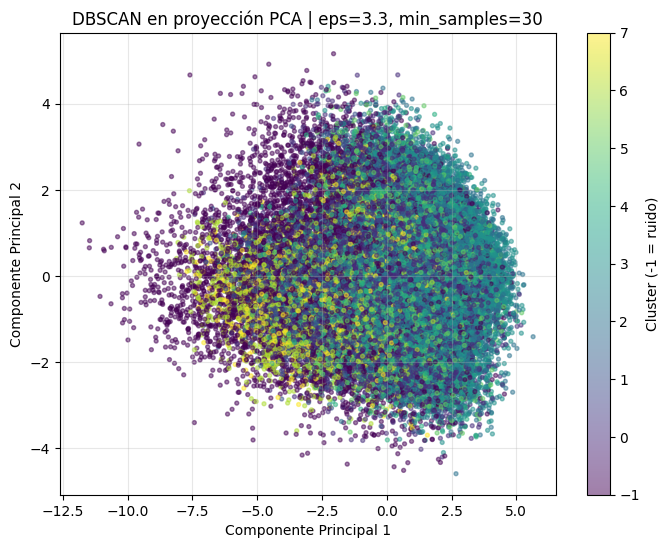

In [ ]:
# 7.8.1 Proyección PCA 2D para visualizar DBSCAN

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_escalado)

print(
    f"Varianza explicada por las dos componentes: "
    f"{pca_2d.explained_variance_ratio_.sum():.2%}"
)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels_dbscan,
    s=8,
    alpha=0.5
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title(
    f"DBSCAN en proyección PCA | "
    f"eps={eps_elegido}, min_samples={min_samples}"
)
plt.colorbar(scatter, label="Cluster (-1 = ruido)")
plt.grid(alpha=0.3)
plt.show()


## **Conclusiones**

Se confirma la hipotesis: los estudiantes no forman un grupo homogeneo, sino perfiles diferenciados detectables sin usar variables de resultado profesional.

**Comparacion.** K-Means (10 clusters) obtuvo silhouette 0.1564, asignando el 100 por ciento de los estudiantes a un grupo. DBSCAN (8 clusters) obtuvo silhouette 0.1725, levemente superior, pero dejo un 14.06 por ciento de los datos como ruido (perfiles atipicos que no encajan en ningun grupo).

**Relevancia practica.** DBSCAN aporta valor al senalar estudiantes atipicos que requieren atencion individual. K-Means aporta una segmentacion completa, util para estrategias generales por grupo.

**Conclusion.** Ningun modelo es superior en terminos absolutos: K-Means conviene para segmentar a toda la poblacion; DBSCAN conviene para detectar casos atipicos que merecen revision particular.
